# VMamba-Tiny vs Fine-Tuned ResNet50: Comprehensive Comparison

This notebook provides a full comparison between:
- **VMamba-Tiny (patch size = 8)**
- **Fine-tuned ResNet50 baseline**

It includes:
1. Training and validation loss curves
2. Validation metric curves (Accuracy and Macro-F1)
3. Confusion matrix for each dataset and each model
4. Efficiency comparison: latency, parameter count, and FLOPs
5. Theoretical time-complexity discussion for both architectures

In [1]:
import os
import sys
import time
import math
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import yaml

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, f1_score
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

plt.style.use("seaborn-v0_8-whitegrid")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# cuBLAS reproducibility guard for deterministic CUDA matmul/linear kernels.
if "CUBLAS_WORKSPACE_CONFIG" not in os.environ:
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

if hasattr(torch.backends, "cudnn"):
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Prefer new TF32 controls when available; fallback to legacy flags.
if hasattr(torch.backends, "cuda") and hasattr(torch.backends.cuda, "matmul"):
    if hasattr(torch.backends.cuda.matmul, "fp32_precision"):
        torch.backends.cuda.matmul.fp32_precision = "ieee"
    elif hasattr(torch.backends.cuda.matmul, "allow_tf32"):
        torch.backends.cuda.matmul.allow_tf32 = False

if hasattr(torch.backends, "cudnn"):
    if hasattr(torch.backends.cudnn, "conv") and hasattr(torch.backends.cudnn.conv, "fp32_precision"):
        torch.backends.cudnn.conv.fp32_precision = "ieee"
    elif hasattr(torch.backends.cudnn, "allow_tf32"):
        torch.backends.cudnn.allow_tf32 = False

# Keep deterministic intent, but avoid hard crashes if an op has no deterministic CUDA path.
try:
    torch.use_deterministic_algorithms(True, warn_only=True)
except TypeError:
    torch.use_deterministic_algorithms(True)


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src").exists() and (candidate / "configs" / "default.yaml").exists():
            return candidate

    nested = start / "MedMamba-XAI"
    if (nested / "src").exists() and (nested / "configs" / "default.yaml").exists():
        return nested

    raise RuntimeError(
        "Could not auto-detect project root. "
        "Expected a folder containing src/ and configs/default.yaml."
    )


PROJECT_ROOT = find_project_root(Path.cwd())
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Notebook cwd: {Path.cwd()}")
print(f"Project root: {PROJECT_ROOT}")
print(f"Device: {device}")
print(f"CUBLAS_WORKSPACE_CONFIG={os.environ.get('CUBLAS_WORKSPACE_CONFIG')}")
print("Deterministic algorithms: enabled (warn_only mode)")
print("For strict CUDA determinism, restart the kernel once after this cell.")

Notebook cwd: /home/group2/youssef/MedMamba-XAI/notebooks
Project root: /home/group2/youssef/MedMamba-XAI
Device: cuda
CUBLAS_WORKSPACE_CONFIG=:4096:8
Deterministic algorithms: enabled (warn_only mode)
For strict CUDA determinism, restart the kernel once after this cell.


/home/group2/youssef/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Experiment Paths and Model Specs

This section maps each dataset to the corresponding run artifacts for each model.

In [2]:
DATASETS = ["pathmnist", "dermamnist", "bloodmnist", "octmnist"]

MODEL_SPECS = {
    "VMamba-Tiny (patch=8)": {
        "short_name": "vmamba_tiny",
        "model_type": "vmamba",
        "metrics_template": "runs/medical_mamba/single_task/patch_8/{dataset}/metrics.csv",
        "checkpoint_template": "runs/medical_mamba/single_task/patch_8/{dataset}/checkpoint_best.pt",
        "color": "#0B6E4F",
    },
    "ResNet50 (fine-tuned)": {
        "short_name": "resnet50",
        "model_type": "resnet50",
        "metrics_template": "runs/resnet_baseline/single_task/{dataset}/metrics.csv",
        "checkpoint_template": "runs/resnet_baseline/single_task/{dataset}/checkpoint_best.pt",
        "color": "#C75C00",
    },
}

def resolve_template(path_template: str, dataset: str) -> Path:
    rel_path = Path(path_template.format(dataset=dataset))
    primary = PROJECT_ROOT / rel_path
    if primary.exists():
        return primary

    # Fallback search makes notebook resilient when launched from different CWDs.
    for root in [Path.cwd(), *Path.cwd().parents]:
        candidate = root / rel_path
        if candidate.exists():
            return candidate

    return primary

def assert_required_artifacts() -> None:
    missing = []
    for dataset in DATASETS:
        for model_name, spec in MODEL_SPECS.items():
            metrics_path = resolve_template(spec["metrics_template"], dataset)
            ckpt_path = resolve_template(spec["checkpoint_template"], dataset)
            if not metrics_path.exists():
                missing.append(str(metrics_path))
            if not ckpt_path.exists():
                missing.append(str(ckpt_path))

    if missing:
        print(f"Missing artifacts: {len(missing)}")
        for path in missing[:20]:
            print(f"  - {path}")
        if len(missing) > 20:
            print(f"  ... and {len(missing) - 20} more")
    else:
        print("All required metrics/checkpoints were found.")

assert_required_artifacts()

All required metrics/checkpoints were found.


## Load Training/Validation Logs

The `metrics.csv` files are merged into one DataFrame for plotting and comparison.

In [3]:
def load_all_metrics() -> pd.DataFrame:
    frames = []
    checked_paths = []

    for dataset in DATASETS:
        for model_name, spec in MODEL_SPECS.items():
            csv_path = resolve_template(spec["metrics_template"], dataset)
            checked_paths.append(csv_path)
            if not csv_path.exists():
                continue

            df = pd.read_csv(csv_path)
            df["dataset"] = dataset
            df["model_name"] = model_name

            # Some runs append resumed logs, which can duplicate epochs.
            if "epoch" in df.columns:
                df["epoch"] = pd.to_numeric(df["epoch"], errors="coerce")
            df = df.dropna(subset=["epoch", "split"]).copy()
            df["epoch"] = df["epoch"].astype(int)

            dup_mask = df.duplicated(subset=["split", "epoch"], keep="last")
            n_dup = int(dup_mask.sum())
            if n_dup > 0:
                print(f"[info] {dataset} | {model_name}: dropped {n_dup} duplicate (split, epoch) rows")
                df = df.loc[~dup_mask].copy()

            df = df.sort_values(["split", "epoch"]).reset_index(drop=True)
            frames.append(df)

    if not frames:
        checked_preview = "\n".join(f"  - {p}" for p in checked_paths[:12])
        raise RuntimeError(
            "No metrics.csv files were loaded.\n"
            f"Current cwd: {Path.cwd()}\n"
            f"Project root: {PROJECT_ROOT}\n"
            "Checked paths (first 12):\n"
            f"{checked_preview}"
        )

    out = pd.concat(frames, ignore_index=True)

    # Build dataset-normalized metric columns to avoid misleading NaNs from other datasets.
    def _pick_metric(row: pd.Series, base_name: str):
        specific = f"{row['dataset']}_{base_name}"
        if specific in row.index and pd.notna(row[specific]):
            return row[specific]
        if base_name in row.index and pd.notna(row[base_name]):
            return row[base_name]
        return np.nan

    out["accuracy"] = out.apply(lambda r: _pick_metric(r, "accuracy"), axis=1)
    out["f1_macro"] = out.apply(lambda r: _pick_metric(r, "f1_macro"), axis=1)
    out["task_loss"] = out.apply(lambda r: _pick_metric(r, "loss"), axis=1)

    return out

def metric_column(df: pd.DataFrame, dataset: str, base_name: str) -> str:
    specific = f"{dataset}_{base_name}"
    if specific in df.columns:
        return specific
    if base_name in df.columns:
        return base_name
    raise KeyError(f"Metric column not found for {dataset=} and {base_name=}")

metrics_df = load_all_metrics()
print(f"Loaded {len(metrics_df):,} metric rows")
preview_cols = ["epoch", "split", "dataset", "model_name", "total_loss", "task_loss", "accuracy", "f1_macro"]
metrics_df[preview_cols].head()

[info] octmnist | VMamba-Tiny (patch=8): dropped 122 duplicate (split, epoch) rows
Loaded 1,372 metric rows


,epoch,split,dataset,model_name,total_loss,task_loss,accuracy,f1_macro
0,0,train,pathmnist,VMamba-Tiny (patch=8),1.534904,1.535517,0.504596,0.491938
1,1,train,pathmnist,VMamba-Tiny (patch=8),1.341887,1.343650,0.591992,0.583087
2,2,train,pathmnist,VMamba-Tiny (patch=8),1.220869,1.223852,0.658331,0.652534
3,3,train,pathmnist,VMamba-Tiny (patch=8),1.113835,1.118055,0.715278,0.712451
4,4,train,pathmnist,VMamba-Tiny (patch=8),1.029150,1.034772,0.755030,0.752432


In [4]:
best_val_rows = []
for dataset in DATASETS:
    for model_name in MODEL_SPECS:
        sub = metrics_df[(metrics_df["dataset"] == dataset) & (metrics_df["model_name"] == model_name)]
        sub = sub[sub["split"] == "val"].copy()
        if sub.empty:
            continue

        acc_col = metric_column(sub, dataset, "accuracy")
        f1_col = metric_column(sub, dataset, "f1_macro")

        best_idx = sub[f1_col].idxmax()
        best_row = sub.loc[best_idx]

        best_val_rows.append({
            "dataset": dataset,
            "model_name": model_name,
            "best_val_epoch": int(best_row["epoch"]),
            "best_val_loss": float(best_row["total_loss"]),
            "best_val_accuracy": float(best_row[acc_col]),
            "best_val_f1_macro": float(best_row[f1_col]),
        })

best_val_df = pd.DataFrame(best_val_rows).sort_values(["dataset", "best_val_f1_macro"], ascending=[True, False])
best_val_df

,dataset,model_name,best_val_epoch,best_val_loss,best_val_accuracy,best_val_f1_macro
5,bloodmnist,ResNet50 (fine-tuned),18,0.486732,0.994743,0.995117
4,bloodmnist,VMamba-Tiny (patch=8),81,0.501338,0.985981,0.986590
3,dermamnist,ResNet50 (fine-tuned),83,0.717368,0.901296,0.830501
2,dermamnist,VMamba-Tiny (patch=8),94,1.011988,0.692921,0.609334
7,octmnist,ResNet50 (fine-tuned),94,0.381299,0.983290,0.970802
6,octmnist,VMamba-Tiny (patch=8),86,0.391701,0.976551,0.960401
1,pathmnist,ResNet50 (fine-tuned),26,0.491503,0.997701,0.997600
0,pathmnist,VMamba-Tiny (patch=8),94,0.491844,0.997401,0.997365


## Loss Curves (Train + Validation)

Each subplot shows both models with train/val loss trajectories for one dataset.

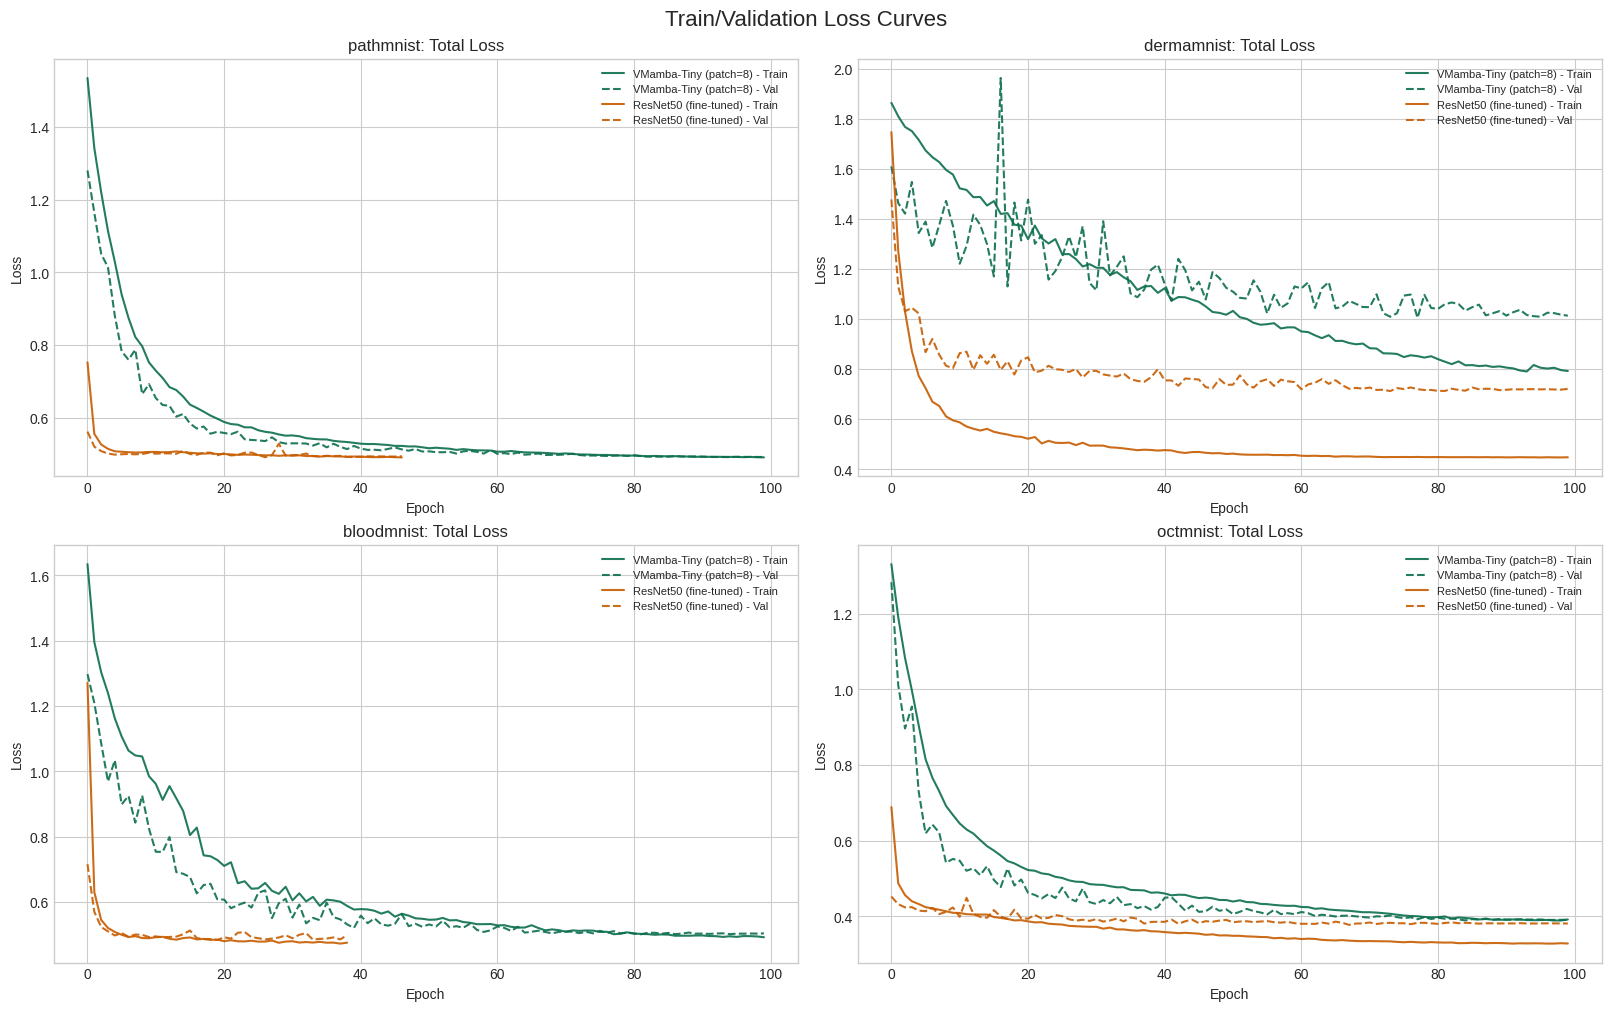

In [5]:
def plot_loss_curves(all_metrics: pd.DataFrame) -> None:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)
    axes = axes.flatten()

    for i, dataset in enumerate(DATASETS):
        ax = axes[i]
        ds = all_metrics[all_metrics["dataset"] == dataset]

        for model_name, spec in MODEL_SPECS.items():
            model_df = ds[ds["model_name"] == model_name]
            train_df = model_df[model_df["split"] == "train"].sort_values("epoch")
            val_df = model_df[model_df["split"] == "val"].sort_values("epoch")

            ax.plot(train_df["epoch"], train_df["total_loss"], label=f"{model_name} - Train", color=spec["color"], linestyle="-", alpha=0.90)
            ax.plot(val_df["epoch"], val_df["total_loss"], label=f"{model_name} - Val", color=spec["color"], linestyle="--", alpha=0.90)

        ax.set_title(f"{dataset}: Total Loss")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.legend(fontsize=8, loc="upper right")

    fig.suptitle("Train/Validation Loss Curves", fontsize=16)
    plt.show()

plot_loss_curves(metrics_df)

## Validation Curves (Accuracy and Macro-F1)

Validation dynamics are shown separately for Accuracy and Macro-F1.

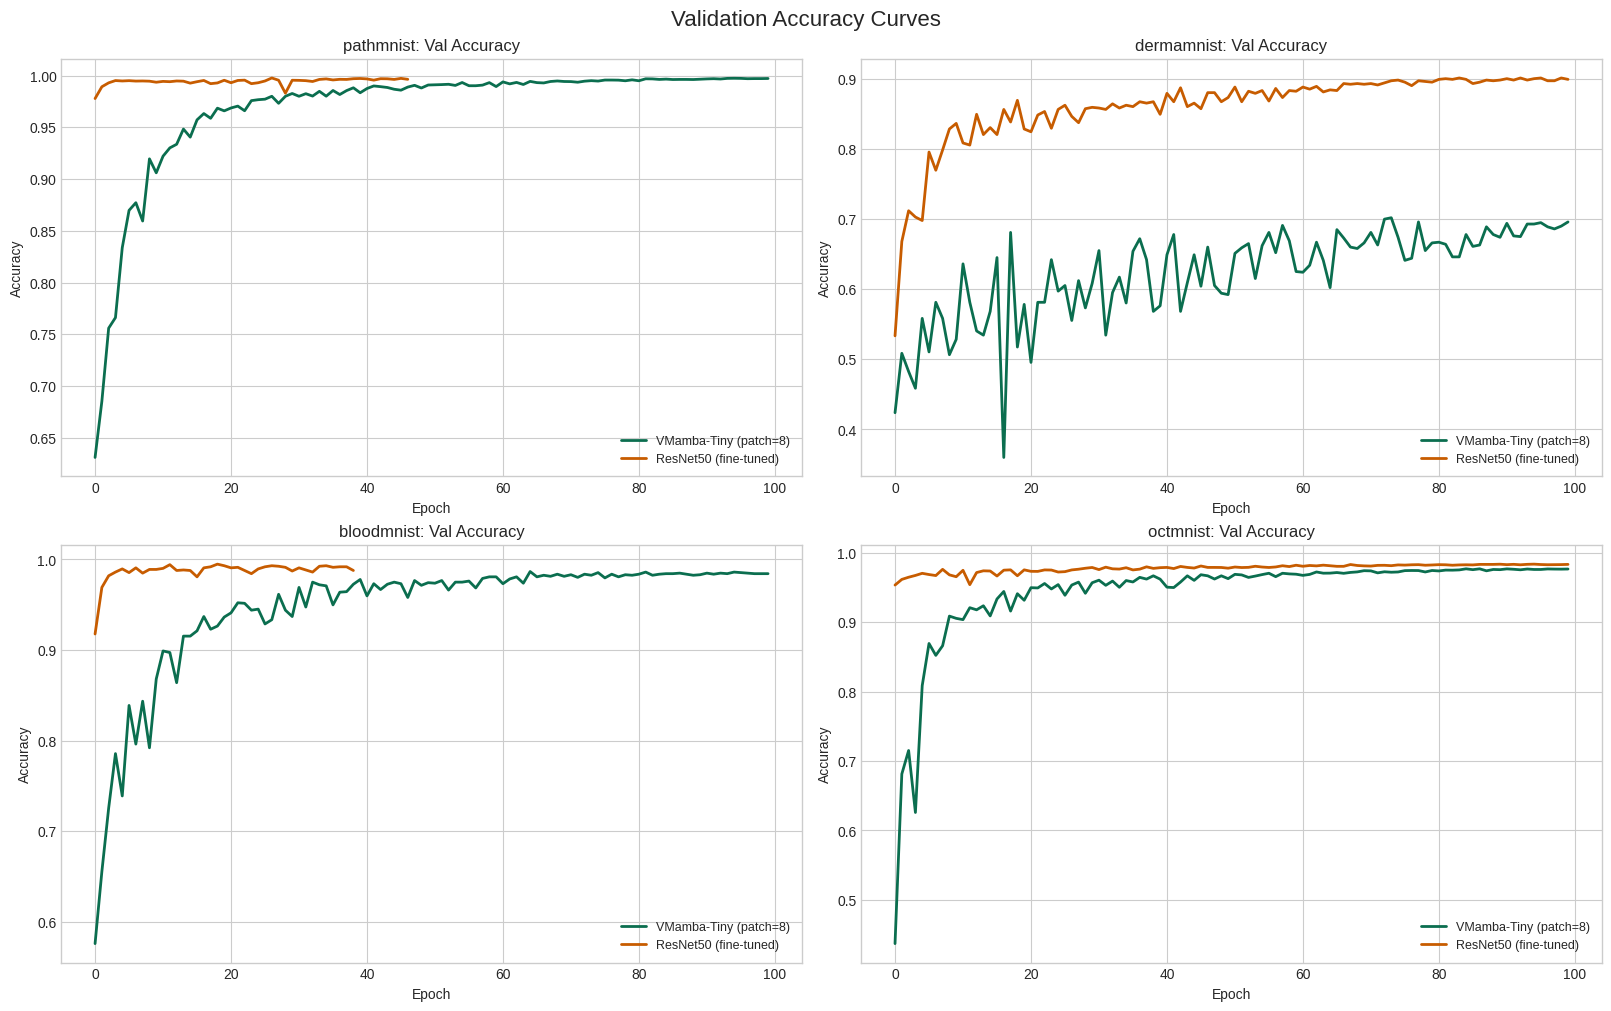

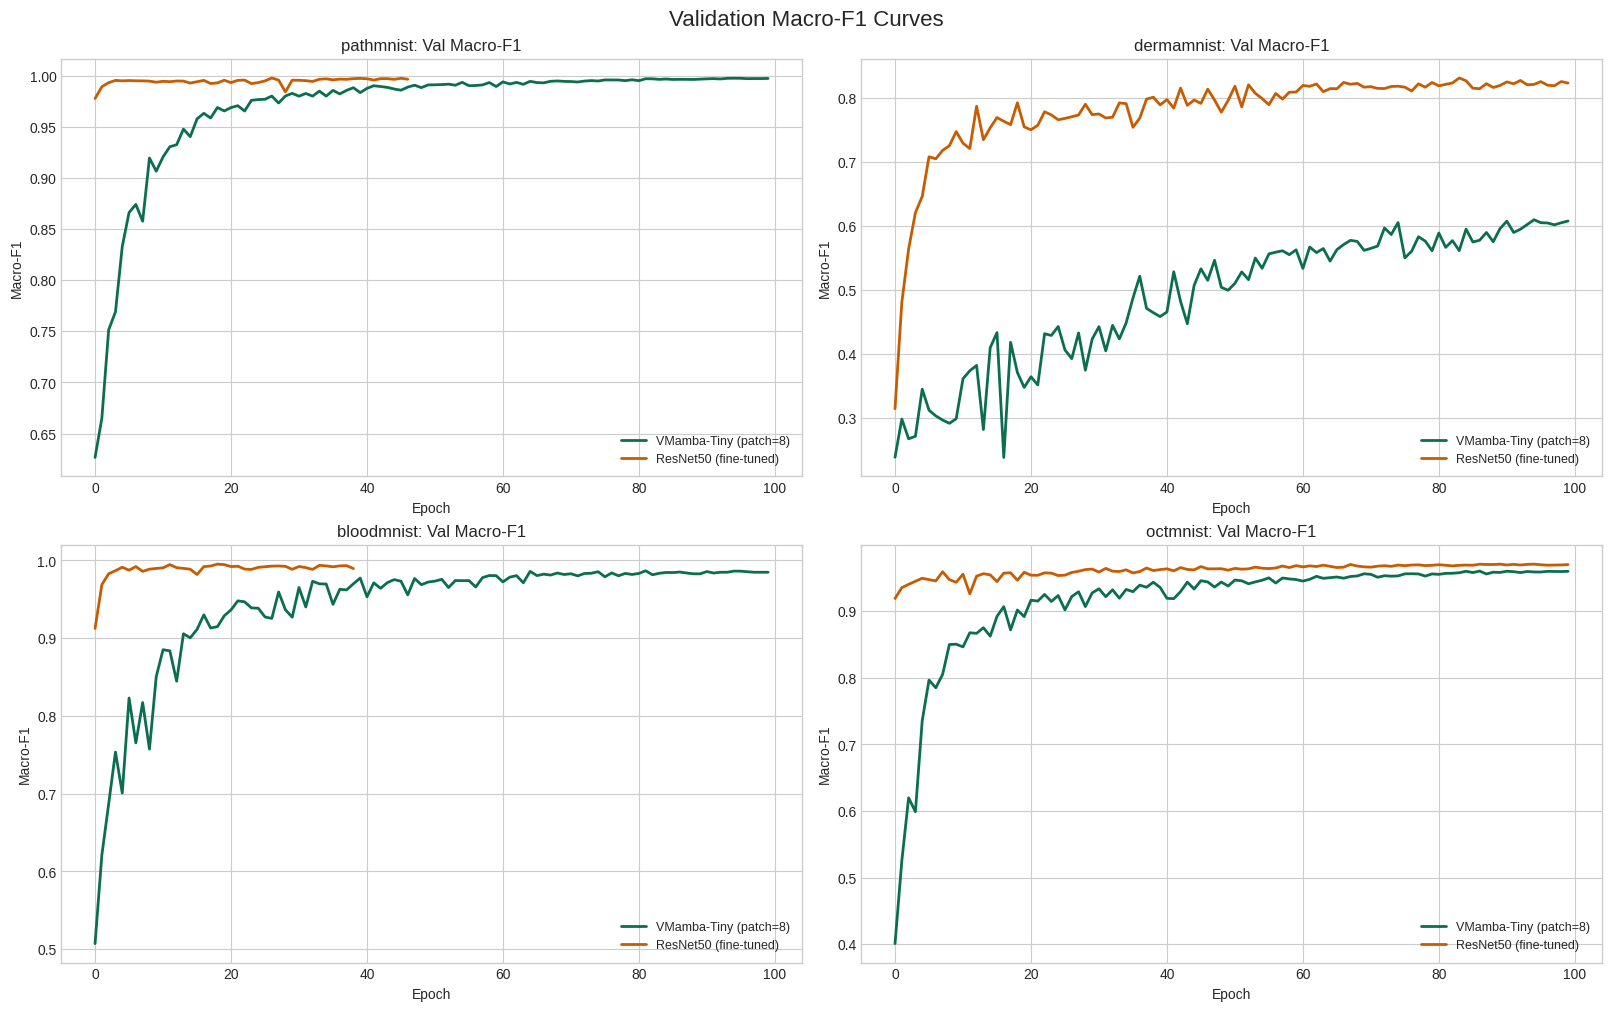

In [6]:
def plot_validation_metric(all_metrics: pd.DataFrame, base_metric: str, title: str, y_label: str) -> None:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)
    axes = axes.flatten()

    for i, dataset in enumerate(DATASETS):
        ax = axes[i]
        ds = all_metrics[(all_metrics["dataset"] == dataset) & (all_metrics["split"] == "val")].copy()

        for model_name, spec in MODEL_SPECS.items():
            model_df = ds[ds["model_name"] == model_name]
            if model_df.empty:
                continue

            col = metric_column(model_df, dataset, base_metric)
            model_df = model_df.sort_values("epoch")
            ax.plot(model_df["epoch"], model_df[col], label=model_name, color=spec["color"], linewidth=2.0)

        ax.set_title(f"{dataset}: Val {y_label}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel(y_label)
        ax.legend(fontsize=9, loc="lower right")

    fig.suptitle(title, fontsize=16)
    plt.show()

plot_validation_metric(metrics_df, base_metric="accuracy", title="Validation Accuracy Curves", y_label="Accuracy")
plot_validation_metric(metrics_df, base_metric="f1_macro", title="Validation Macro-F1 Curves", y_label="Macro-F1")

## Confusion Matrices on Test Sets

For each dataset and each model, this section loads the best checkpoint and computes test predictions, then visualizes normalized confusion matrices.

In [7]:
from medical_mamba.data.constants import DATASET_META
from medical_mamba.data.dataset import MedMNISTFolder
from medical_mamba.data.transforms import build_transforms_map
from medical_mamba.models.medical_vmamba import build_model
from medical_mamba.models.resnet_baseline import ResNetBaseline

with open(PROJECT_ROOT / "configs/default.yaml", "r") as f:
    default_cfg = yaml.safe_load(f)

DATA_ROOTS = {k: PROJECT_ROOT / v for k, v in default_cfg["data"]["roots"].items()}
IMG_SIZE = int(default_cfg.get("data", {}).get("img_size", 224))
EVAL_BATCH_SIZE = 64 if device.type == "cuda" else 32
EVAL_NUM_WORKERS = min(4, int(default_cfg.get("project", {}).get("num_workers", 4)))

print(f"Evaluation batch size: {EVAL_BATCH_SIZE}, workers: {EVAL_NUM_WORKERS}")

TRANSFORMS_MAP = build_transforms_map(DATASETS, img_size=IMG_SIZE)

def load_checkpoint_state(path: Path, map_location: torch.device):
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)

def sanitize_state_dict(state_dict: dict) -> dict:
    keys = list(state_dict.keys())
    if keys and all(k.startswith("module.") for k in keys):
        return {k[len("module."):]: v for k, v in state_dict.items()}
    return state_dict

def build_test_loader(dataset: str) -> DataLoader:
    ds = MedMNISTFolder(
        dataset_name=dataset,
        root=DATA_ROOTS[dataset],
        split="test",
        transform=TRANSFORMS_MAP[dataset]["test"],
        task_id=0,
    )
    return DataLoader(
        ds,
        batch_size=EVAL_BATCH_SIZE,
        shuffle=False,
        num_workers=EVAL_NUM_WORKERS,
        pin_memory=(device.type == "cuda"),
    )

def load_model_for_dataset(model_name: str, dataset: str) -> torch.nn.Module:
    spec = MODEL_SPECS[model_name]
    task_configs = [(dataset, DATASET_META[dataset]["num_classes"])]

    if spec["model_type"] == "vmamba":
        model = build_model(
            task_configs=task_configs,
            model_size="tiny",
            patch_size=8,
            head_dropout=0.1,
        )
    elif spec["model_type"] == "resnet50":
        model = ResNetBaseline(task_configs=task_configs, pretrained=False, head_dropout=0.1)
    else:
        raise ValueError(f"Unsupported model type: {spec['model_type']}")

    checkpoint_path = resolve_template(spec["checkpoint_template"], dataset)
    state = load_checkpoint_state(checkpoint_path, map_location=device)
    state_dict = state["model_state_dict"] if isinstance(state, dict) and "model_state_dict" in state else state
    state_dict = sanitize_state_dict(state_dict)

    model.load_state_dict(state_dict, strict=True)
    model = model.to(device).eval()
    return model

@torch.inference_mode()
def _run_inference_once(model: torch.nn.Module, loader: DataLoader, task_name: str):
    all_true = []
    all_pred = []

    for batch in tqdm(loader, desc=f"Inference - {task_name}", leave=False):
        images = batch["image"].to(device, non_blocking=True)
        labels = batch["label"].cpu().numpy()

        # Suppress repetitive warn_only deterministic messages from cuBLAS fallback paths.
        with warnings.catch_warnings():
            warnings.filterwarnings(
                "ignore",
                message="Deterministic behavior was enabled.*CuBLAS.*",
                category=UserWarning,
            )
            logits, _ = model(images, task_name)

        preds = logits.argmax(dim=1).detach().cpu().numpy()

        all_true.append(labels)
        all_pred.append(preds)

    y_true = np.concatenate(all_true, axis=0)
    y_pred = np.concatenate(all_pred, axis=0)
    return y_true, y_pred

@torch.inference_mode()
def run_inference(model: torch.nn.Module, loader: DataLoader, task_name: str):
    try:
        return _run_inference_once(model, loader, task_name)
    except RuntimeError as err:
        msg = str(err)
        if "CUBLAS_WORKSPACE_CONFIG" not in msg and "deterministic" not in msg.lower():
            raise

        warnings.warn(
            "Deterministic CUDA constraint triggered during inference. "
            "Retrying with deterministic_algorithms=False for this pass.",
            RuntimeWarning,
        )

        prev_enabled = torch.are_deterministic_algorithms_enabled()
        torch.use_deterministic_algorithms(False)
        try:
            return _run_inference_once(model, loader, task_name)
        finally:
            if prev_enabled:
                try:
                    torch.use_deterministic_algorithms(True, warn_only=True)
                except TypeError:
                    torch.use_deterministic_algorithms(True)

/home/group2/youssef/.venv/lib/python3.11/site-packages/mamba_ssm/utils/determinism.py:73: UserWarning: Deterministic mode: set TRITON_CACHE_AUTOTUNING=1 for cached autotuning.
  warnings.warn(msg)
/home/group2/youssef/MedMamba-XAI/src/medical_mamba/models/backbone.py:39: UserWarning: mamba-ssm not installed. Using pure-PyTorch SSM fallback — correct but ~10× slower. Install with: pip install mamba-ssm causal-conv1d
  from medical_mamba.models.blocks import VSSBlock
2026-04-13 15:32:15.090688: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Evaluation batch size: 64, workers: 4


/home/group2/youssef/.venv/lib/python3.11/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [8]:
CACHE_DIR = PROJECT_ROOT / "notebooks" / "cache" / "vmamba_vs_resnet50"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

prediction_cache = {}
test_rows = []

for dataset in DATASETS:
    test_loader = build_test_loader(dataset)

    for model_name, spec in MODEL_SPECS.items():
        cache_file = CACHE_DIR / f"preds__{spec['short_name']}__{dataset}.npz"

        if cache_file.exists():
            cached = np.load(cache_file)
            y_true = cached["y_true"]
            y_pred = cached["y_pred"]
        else:
            model = load_model_for_dataset(model_name, dataset)
            y_true, y_pred = run_inference(model, test_loader, dataset)
            np.savez_compressed(cache_file, y_true=y_true, y_pred=y_pred)

        prediction_cache[(model_name, dataset)] = (y_true, y_pred)

        test_rows.append({
            "dataset": dataset,
            "model_name": model_name,
            "test_accuracy": float(accuracy_score(y_true, y_pred)),
            "test_f1_macro": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        })

test_summary_df = pd.DataFrame(test_rows).sort_values(["dataset", "test_f1_macro"], ascending=[True, False])
test_summary_df

,dataset,model_name,test_accuracy,test_f1_macro
5,bloodmnist,ResNet50 (fine-tuned),0.987431,0.988418
4,bloodmnist,VMamba-Tiny (patch=8),0.986261,0.987845
3,dermamnist,ResNet50 (fine-tuned),0.904738,0.846402
2,dermamnist,VMamba-Tiny (patch=8),0.699252,0.598200
6,octmnist,VMamba-Tiny (patch=8),0.932000,0.931443
7,octmnist,ResNet50 (fine-tuned),0.891000,0.889797
1,pathmnist,ResNet50 (fine-tuned),0.959610,0.948739
0,pathmnist,VMamba-Tiny (patch=8),0.941922,0.928781


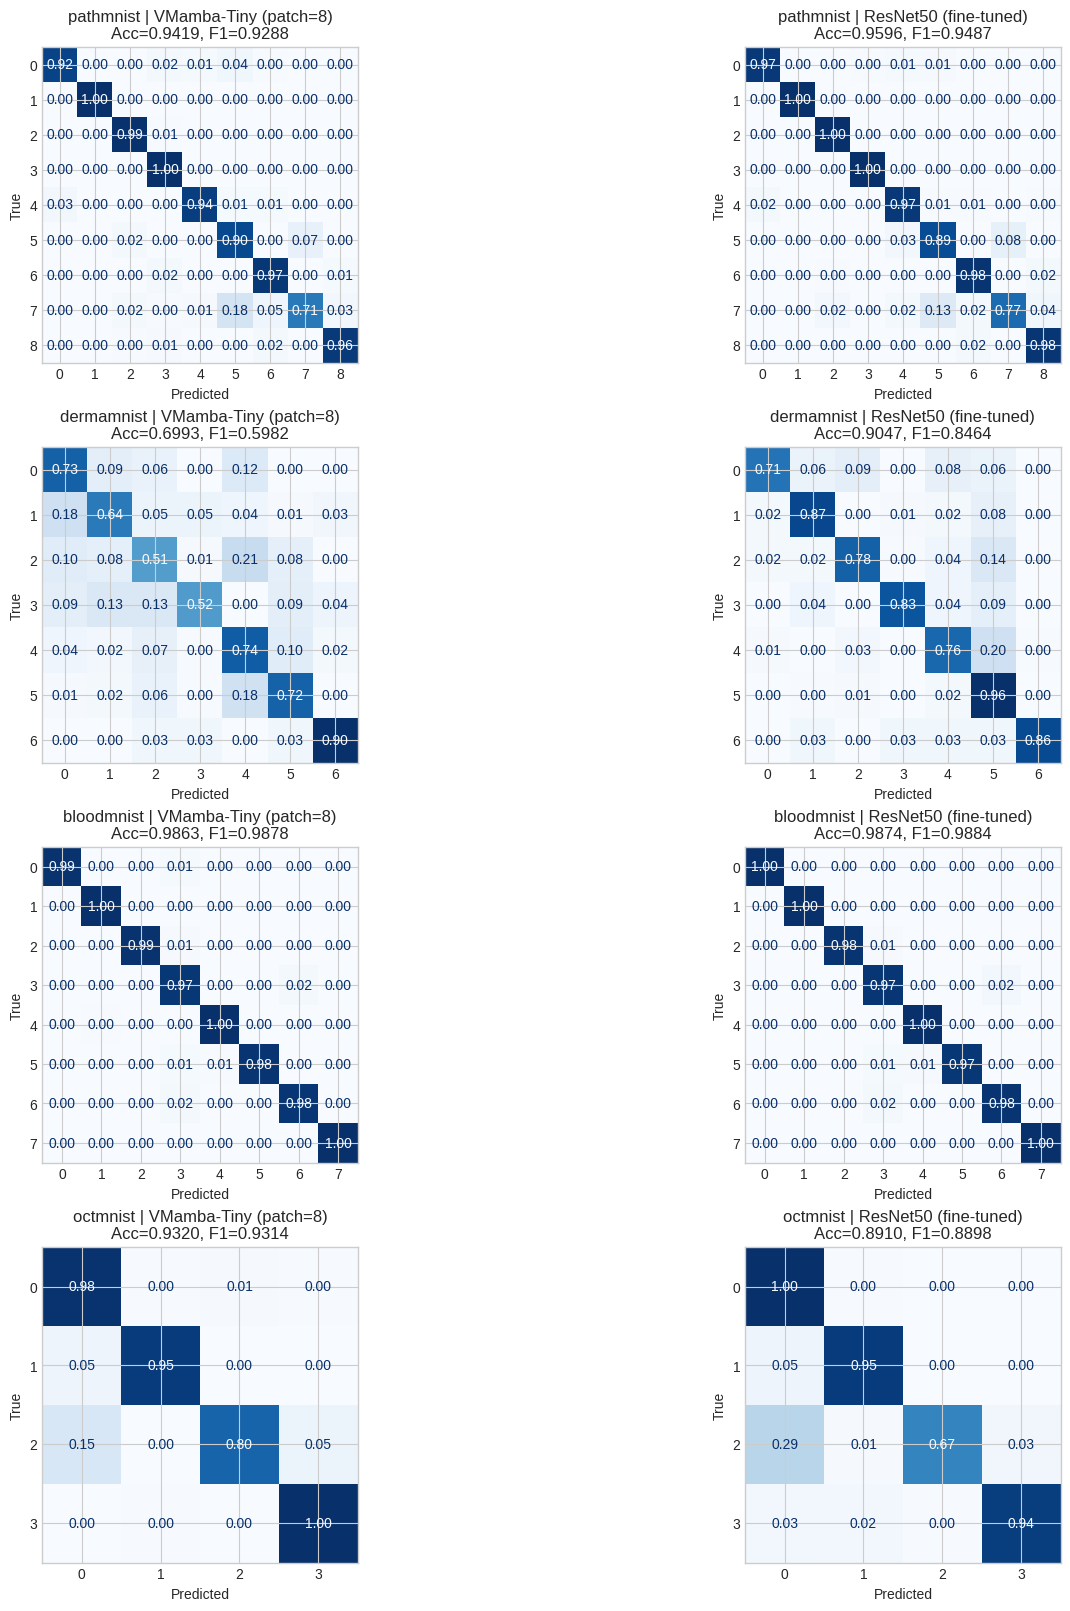

In [9]:
model_names = list(MODEL_SPECS.keys())

fig, axes = plt.subplots(len(DATASETS), len(model_names), figsize=(14, 4 * len(DATASETS)), constrained_layout=True)
if len(DATASETS) == 1:
    axes = np.array([axes])

for i, dataset in enumerate(DATASETS):
    for j, model_name in enumerate(model_names):
        ax = axes[i, j]
        y_true, y_pred = prediction_cache[(model_name, dataset)]

        n_classes = DATASET_META[dataset]["num_classes"]
        labels = np.arange(n_classes)
        cm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true")

        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
        disp.plot(ax=ax, cmap="Blues", values_format=".2f", colorbar=False)

        acc = accuracy_score(y_true, y_pred)
        f1m = f1_score(y_true, y_pred, average="macro", zero_division=0)
        ax.set_title(f"{dataset} | {model_name}\nAcc={acc:.4f}, F1={f1m:.4f}")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")

plt.show()

## Efficiency Focus

This section provides empirical efficiency results for each model/dataset pair:
- Parameter count
- FLOPs (from `torch.profiler` when available)
- Inference latency (warmup + timed runs)

In [10]:
try:
    from torch.profiler import profile, ProfilerActivity
    HAS_TORCH_PROFILER = True
except Exception as err:
    HAS_TORCH_PROFILER = False
    print(f"[warn] torch.profiler unavailable: {err}")

def count_parameters(model: torch.nn.Module) -> int:
    return int(sum(p.numel() for p in model.parameters()))

@torch.inference_mode()
def benchmark_latency_ms(
    model: torch.nn.Module,
    task_name: str,
    input_tensor: torch.Tensor,
    warmup: int = 20,
    iters: int = 100,
) -> dict:
    for _ in range(warmup):
        _ = model(input_tensor, task_name)

    if device.type == "cuda":
        torch.cuda.synchronize()

    times = []
    for _ in range(iters):
        t0 = time.perf_counter()
        _ = model(input_tensor, task_name)
        if device.type == "cuda":
            torch.cuda.synchronize()
        times.append((time.perf_counter() - t0) * 1000.0)

    arr = np.asarray(times, dtype=np.float64)
    return {
        "latency_mean_ms": float(arr.mean()),
        "latency_std_ms": float(arr.std(ddof=1) if arr.size > 1 else 0.0),
        "latency_p50_ms": float(np.percentile(arr, 50)),
        "latency_p95_ms": float(np.percentile(arr, 95)),
    }

@torch.inference_mode()
def estimate_flops_profiler(model: torch.nn.Module, task_name: str, input_tensor: torch.Tensor) -> float:
    if not HAS_TORCH_PROFILER:
        return float("nan")

    activities = [ProfilerActivity.CPU]
    if device.type == "cuda":
        activities.append(ProfilerActivity.CUDA)

    try:
        with profile(activities=activities, record_shapes=False, profile_memory=False, with_flops=True) as prof:
            _ = model(input_tensor, task_name)

        total_flops = 0
        for evt in prof.key_averages():
            flops = getattr(evt, "flops", 0)
            if flops is not None:
                total_flops += flops

        if total_flops <= 0:
            return float("nan")

        return float(total_flops)
    except Exception as err:
        warnings.warn(f"FLOPs profiling failed for {task_name}: {err}")
        return float("nan")

EFF_CSV = CACHE_DIR / "efficiency_results.csv"
RECOMPUTE_EFFICIENCY = False

if EFF_CSV.exists() and not RECOMPUTE_EFFICIENCY:
    efficiency_df = pd.read_csv(EFF_CSV)
else:
    eff_rows = []

    warmup = 20 if device.type == "cuda" else 5
    iters = 100 if device.type == "cuda" else 30

    for dataset in DATASETS:
        sample = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=device)

        for model_name, spec in MODEL_SPECS.items():
            model = load_model_for_dataset(model_name, dataset)

            params = count_parameters(model)
            flops = estimate_flops_profiler(model, dataset, sample)
            latency = benchmark_latency_ms(model, dataset, sample, warmup=warmup, iters=iters)

            row = {
                "dataset": dataset,
                "model_name": model_name,
                "params": params,
                "flops": flops,
            }
            row.update(latency)
            eff_rows.append(row)

    efficiency_df = pd.DataFrame(eff_rows)
    efficiency_df.to_csv(EFF_CSV, index=False)

efficiency_df["params_M"] = efficiency_df["params"] / 1e6
efficiency_df["flops_G"] = efficiency_df["flops"] / 1e9
efficiency_df = efficiency_df.sort_values(["dataset", "model_name"]).reset_index(drop=True)
efficiency_df

,dataset,model_name,params,flops,latency_mean_ms,latency_std_ms,latency_p50_ms,latency_p95_ms,params_M,flops_G
0,bloodmnist,ResNet50 (fine-tuned),23528520,8.174305e+09,8.145280,0.019328,8.141578,8.180714,23.528520,8.174305
1,bloodmnist,VMamba-Tiny (patch=8),49471592,1.198789e+10,50.160570,0.054301,50.157096,50.246384,49.471592,11.987893
2,dermamnist,ResNet50 (fine-tuned),23526471,8.174301e+09,8.150888,0.018817,8.149123,8.186242,23.526471,8.174301
3,dermamnist,VMamba-Tiny (patch=8),49470823,1.198789e+10,50.113351,0.054199,50.111380,50.195328,49.470823,11.987892
4,octmnist,ResNet50 (fine-tuned),23520324,8.174289e+09,8.175225,0.050969,8.160706,8.288088,23.520324,8.174289
5,octmnist,VMamba-Tiny (patch=8),49468516,1.198789e+10,50.137661,0.052793,50.137238,50.215210,49.468516,11.987887
6,pathmnist,ResNet50 (fine-tuned),23530569,8.174309e+09,8.161778,0.022117,8.161613,8.194882,23.530569,8.174309
7,pathmnist,VMamba-Tiny (patch=8),49472361,1.198789e+10,50.117847,1.513290,49.778461,50.302174,49.472361,11.987895


In [11]:
efficiency_agg = (
    efficiency_df.groupby("model_name", as_index=False)[["params_M", "flops_G", "latency_mean_ms", "latency_p95_ms"]]
    .mean()
    .sort_values("latency_mean_ms")
)

print("Average efficiency across datasets:")
efficiency_agg

Average efficiency across datasets:


,model_name,params_M,flops_G,latency_mean_ms,latency_p95_ms
0,ResNet50 (fine-tuned),23.526471,8.174301,8.158293,8.212482
1,VMamba-Tiny (patch=8),49.470823,11.987892,50.132357,50.239774


In [12]:
overall_comparison_df = test_summary_df.merge(
    efficiency_df[["dataset", "model_name", "params_M", "flops_G", "latency_mean_ms", "latency_p95_ms"]],
    on=["dataset", "model_name"],
    how="left",
)

overall_comparison_df = overall_comparison_df.sort_values(["dataset", "test_f1_macro"], ascending=[True, False])
overall_comparison_df

,dataset,model_name,test_accuracy,test_f1_macro,params_M,flops_G,latency_mean_ms,latency_p95_ms
0,bloodmnist,ResNet50 (fine-tuned),0.987431,0.988418,23.528520,8.174305,8.145280,8.180714
1,bloodmnist,VMamba-Tiny (patch=8),0.986261,0.987845,49.471592,11.987893,50.160570,50.246384
2,dermamnist,ResNet50 (fine-tuned),0.904738,0.846402,23.526471,8.174301,8.150888,8.186242
3,dermamnist,VMamba-Tiny (patch=8),0.699252,0.598200,49.470823,11.987892,50.113351,50.195328
4,octmnist,VMamba-Tiny (patch=8),0.932000,0.931443,49.468516,11.987887,50.137661,50.215210
5,octmnist,ResNet50 (fine-tuned),0.891000,0.889797,23.520324,8.174289,8.175225,8.288088
6,pathmnist,ResNet50 (fine-tuned),0.959610,0.948739,23.530569,8.174309,8.161778,8.194882
7,pathmnist,VMamba-Tiny (patch=8),0.941922,0.928781,49.472361,11.987895,50.117847,50.302174


## Theoretical Time Complexity

Let the input image size be $R \times R$.

### ResNet50
A convolution layer cost is approximately:
$$
\text{FLOPs}_l \approx 2 H_l W_l C_l^{in} C_l^{out} k_l^2
$$
Total complexity is the sum over all convolution layers. For fixed depth and channel schedule, scaling with image size is roughly:
$$
\mathcal{O}(R^2)
$$

### VMamba-Tiny (hierarchical VSS blocks)
With patch size $p$, token count is $N = (R/p)^2$.
For one VSS block (4-direction cross scan), a practical complexity decomposition is:
$$
\mathcal{O}(N d k^2) + \mathcal{O}(4 N d s) + \mathcal{O}(2 r N d^2)
$$
where:
- $d$: embedding dimension
- $k$: depthwise conv kernel size
- $s$: state dimension in selective scan
- $r$: MLP ratio

Across stages:
$$
\sum_{i=1}^{S} L_i \left(\mathcal{O}(N_i d_i k^2) + \mathcal{O}(4 N_i d_i s) + \mathcal{O}(2 r N_i d_i^2)\right)
$$
with stage depth $L_i$, token count $N_i$, and width $d_i$.

Key point: selective scan is **linear in token count** $N$, unlike self-attention's quadratic term $\mathcal{O}(N^2 d)$.

In [13]:
def vmamba_stage_complexity_table(
    img_size: int = 224,
    patch_size: int = 8,
    embed_dim: int = 96,
    depths=(2, 2, 6, 2),
    mlp_ratio: float = 4.0,
) -> pd.DataFrame:
    n_tokens = (img_size // patch_size) ** 2
    d = embed_dim

    rows = []
    for stage_idx, depth in enumerate(depths):
        # Relative coefficient (drops constants and lower-order terms): depth * N * d^2
        relative_coeff = depth * n_tokens * (d ** 2)
        rows.append({
            "stage": stage_idx,
            "depth": depth,
            "tokens_N": n_tokens,
            "dim_d": d,
            "relative_coeff_depth_N_d2": relative_coeff,
        })

        if stage_idx < len(depths) - 1:
            n_tokens = n_tokens // 4
            d = d * 2

    out = pd.DataFrame(rows)
    out["relative_share"] = out["relative_coeff_depth_N_d2"] / out["relative_coeff_depth_N_d2"].sum()
    return out

vmamba_stage_complexity_table()

,stage,depth,tokens_N,dim_d,relative_coeff_depth_N_d2,relative_share
0,0,2,784,96,14450688,0.167235
1,1,2,196,192,14450688,0.167235
2,2,6,49,384,43352064,0.501706
3,3,2,12,768,14155776,0.163823


## Final Notes

- If FLOPs appear as `NaN` on your machine, this is usually a profiler limitation for some ops/builds; latency and parameter comparisons remain valid.
- Prediction and efficiency outputs are cached in `notebooks/cache/vmamba_vs_resnet50` to avoid recomputation on reruns.
- To force fresh measurements, set `RECOMPUTE_EFFICIENCY = True` in the efficiency cell and remove cached prediction files if needed.